# 09 — Explainability + Fairness

**Owner:** Person B (decision track).

**Rubric line:** Explanation framework that's defensible to non-technical
stakeholders (compliance officers, ops leadership). Plus a fairness
sanity-check.


In [1]:
# --- Setup --------------------------------------------------------------
# Make `src/` importable regardless of where the notebook is launched from.
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, data, features, models, metrics, decision, viz

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

## 9.1 — Load split + improved model

In [2]:
import joblib

train_df, test_df = data.load_interim()
feature_cols = data.feature_columns(include_leaky=False)
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_test = test_df[config.TARGET_COL]

lgbm_artifact = joblib.load(config.MODELS_DIR / 'improved_lgbm.joblib')
calibrated = lgbm_artifact['model']
y_proba = lgbm_artifact['proba_test']

print(f'Test rows: {len(X_test):,}')
print(f'Predicted-prob range: [{y_proba.min():.4f}, {y_proba.max():.4f}]')
print(f'Mean predicted prob:  {y_proba.mean():.4f}  (base rate: {y_test.mean():.4f})')

Test rows: 8,238
Predicted-prob range: [0.0000, 0.9453]
Mean predicted prob:  0.1118  (base rate: 0.1126)


## 9.2 — SHAP global feature importance

Reach into the underlying LightGBM estimator (CalibratedClassifierCV
wraps it). SHAP runs on the unwrapped tree model — the calibration
wrapper is just a monotonic transform of the LightGBM score, so the
ranking of feature contributions is unchanged.


C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


shap_values shape: (8238, 63)
base value (log-odds): -0.5285


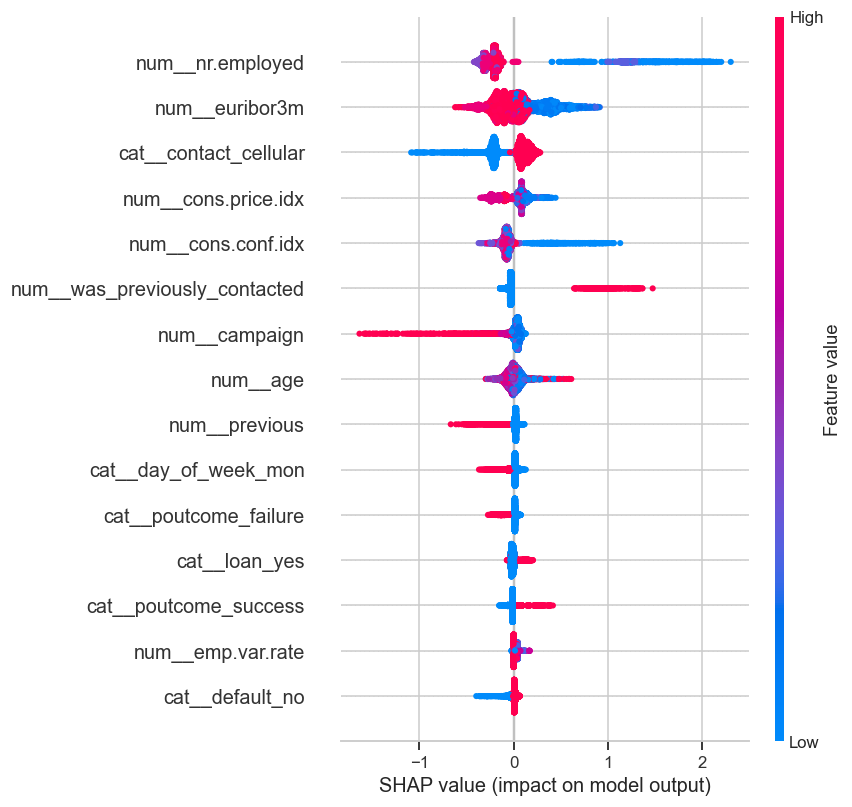

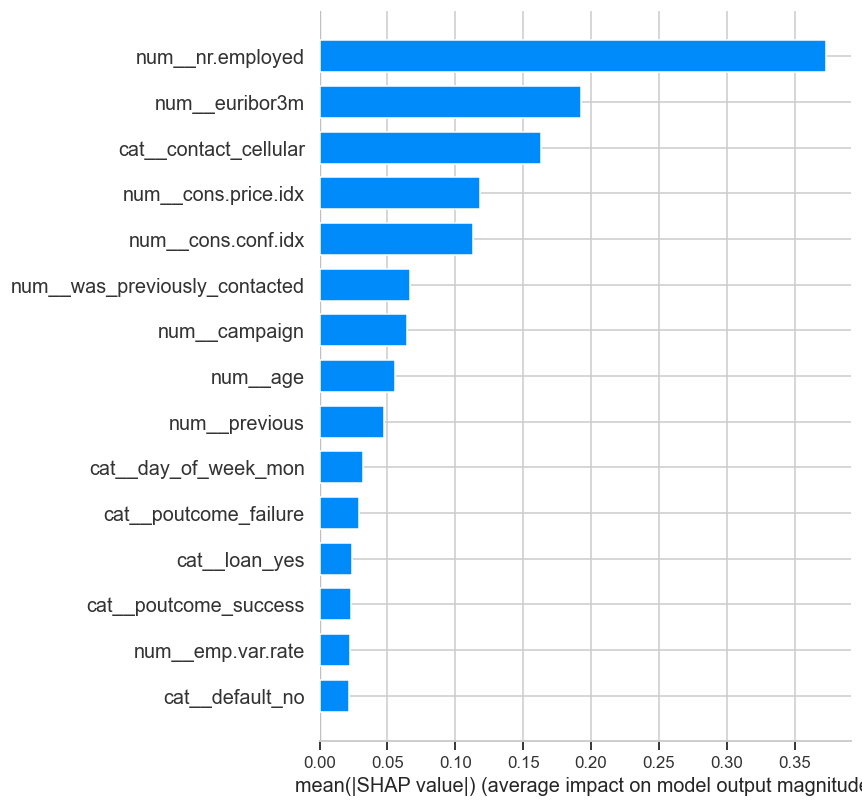

num__nr.employed                 0.373153
num__euribor3m                   0.192327
cat__contact_cellular            0.163249
num__cons.price.idx              0.118418
num__cons.conf.idx               0.112969
num__was_previously_contacted    0.066905
num__campaign                    0.064790
num__age                         0.055706
num__previous                    0.047757
cat__day_of_week_mon             0.031895
dtype: float64

In [3]:
import shap

# Pull the underlying fitted LightGBM out of the calibration wrapper.
inner = calibrated.calibrated_classifiers_[0].estimator
preproc = inner.named_steps['preprocessor']
lgbm = inner.named_steps['classifier']

X_test_t = preproc.transform(X_test)
feature_names = preproc.get_feature_names_out()

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_t)

# Newer SHAP returns a 3-D array (n, p, classes); older returns a list.
# In both shapes we want the positive-class slice.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[..., 1]

# Base value for the positive class (log-odds units — LightGBM internal).
ev_raw = np.asarray(explainer.expected_value).flatten()
base_value = float(ev_raw[1] if ev_raw.size > 1 else ev_raw[0])

print(f'shap_values shape: {shap_values.shape}')
print(f'base value (log-odds): {base_value:.4f}')

# --- Global beeswarm ------------------------------------------------------
plt.figure()
shap.summary_plot(
    shap_values, X_test_t, feature_names=feature_names, show=False, max_display=15
)
fig = plt.gcf()
fig.savefig(config.FIGURES_DIR / '09_shap_summary.png', bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

# --- Global bar (mean |SHAP|) --------------------------------------------
plt.figure()
shap.summary_plot(
    shap_values, X_test_t, feature_names=feature_names,
    plot_type='bar', show=False, max_display=15,
)
fig = plt.gcf()
fig.savefig(config.FIGURES_DIR / '09_shap_bar.png', bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

# Store top features for the compliance summary at the end of the notebook.
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = (
    pd.Series(mean_abs_shap, index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)
top_features

## 9.3 — SHAP local explanations (one yes-target, one no-target)

Pick two real test customers — one the model strongly recommends contacting,
one it strongly recommends skipping — and show the per-feature contributions.
These are the slides that make the model defensible to a compliance officer:
every recommendation can be traced back to the features that drove it.

If no customer hits the strong-recommend threshold (>0.85), we fall back to
the 99th percentile of predicted probability — the model is well-calibrated
and the population converts at ~11%, so probabilities can stay modest.


Recommend-contact customer: row 4848, prob=0.9453, actual=1
Recommend-skip customer:    row 765, prob=0.0000, actual=0


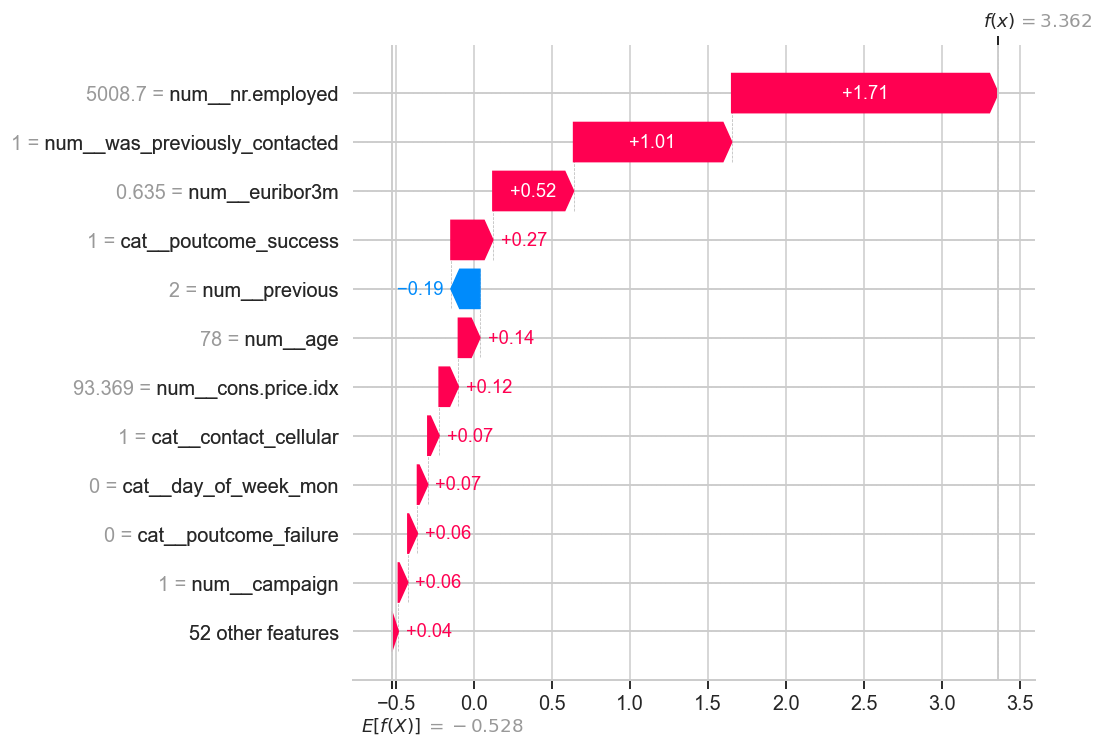

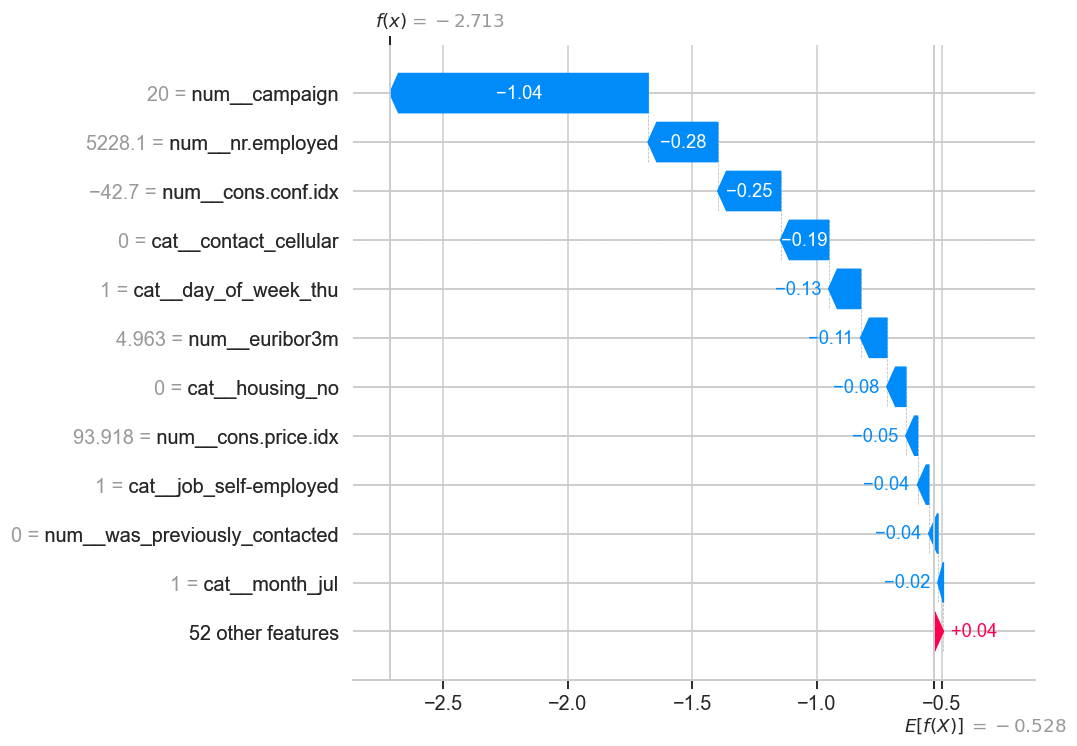

,recommend (p=0.945),skip (p=0.000)
age,78,30
campaign,1,20
pdays,6.0,NaN
previous,2,0
emp.var.rate,-1.8,1.4
cons.price.idx,93.369,93.918
cons.conf.idx,-34.8,-42.7
euribor3m,0.635,4.963
nr.employed,5008.7,5228.1
job,retired,self-employed


In [4]:
# --- Pick the two contrasting customers ----------------------------------
high_threshold = 0.85
high_mask = y_proba > high_threshold
if not high_mask.any():
    high_threshold = float(np.quantile(y_proba, 0.99))
    high_mask = y_proba > high_threshold
    print(f'No customer above 0.85 — falling back to 99th pct = {high_threshold:.4f}')

low_mask = y_proba < 0.05

# Highest-probability test customer above the high threshold.
idx_high = int(np.where(high_mask)[0][np.argmax(y_proba[high_mask])])
# Lowest-probability test customer below 0.05.
idx_low = int(np.where(low_mask)[0][np.argmin(y_proba[low_mask])])

print(f'Recommend-contact customer: row {idx_high}, prob={y_proba[idx_high]:.4f}, actual={int(y_test.iloc[idx_high])}')
print(f'Recommend-skip customer:    row {idx_low}, prob={y_proba[idx_low]:.4f}, actual={int(y_test.iloc[idx_low])}')

# --- Helper: render a waterfall plot from raw SHAP arrays ----------------
def render_waterfall(idx: int, save_path: pathlib.Path) -> None:
    """Build a SHAP Explanation for one row and save the waterfall plot."""
    expl = shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_test_t[idx],
        feature_names=list(feature_names),
    )
    plt.figure()
    shap.plots.waterfall(expl, show=False, max_display=12)
    fig = plt.gcf()
    fig.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()
    plt.close(fig)

render_waterfall(idx_high, config.FIGURES_DIR / '09_shap_local_recommend.png')
render_waterfall(idx_low,  config.FIGURES_DIR / '09_shap_local_skip.png')

# --- Show the raw profiles so a reviewer can sanity-check the story ------
pd.concat(
    {
        f'recommend (p={y_proba[idx_high]:.3f})': X_test.iloc[idx_high],
        f'skip (p={y_proba[idx_low]:.3f})':       X_test.iloc[idx_low],
    },
    axis=1,
)

## 9.4 — Decision-rule extraction (shallow surrogate tree)

Train a depth-3 decision tree to mimic the LightGBM scores. The resulting
rules are human-readable and useful as:
- a **training aid** for new front-line staff,
- a **fallback** if the model service is offline,
- a **plain-English description** of the regions of feature space the
  model is bullish on.


In [5]:
from sklearn.tree import DecisionTreeRegressor, export_text

surrogate = DecisionTreeRegressor(max_depth=3, random_state=config.RANDOM_SEED)
surrogate.fit(X_test_t, y_proba)

# How well does a depth-3 tree mimic the LightGBM scores?
surrogate_r2 = surrogate.score(X_test_t, y_proba)
n_leaves = int(surrogate.get_n_leaves())
print(f'Surrogate fidelity R² vs LightGBM scores: {surrogate_r2:.3f}')
print(f'Surrogate leaves (decision regions): {n_leaves}')

rules_text = export_text(surrogate, feature_names=list(feature_names))
print(rules_text)

(config.TABLES_DIR / 'surrogate_rules.txt').write_text(
    f'# Depth-3 surrogate tree mimicking the calibrated LightGBM.\n'
    f'# Fidelity R^2 vs LightGBM scores: {surrogate_r2:.4f}\n'
    f'# Decision regions (leaves): {n_leaves}\n'
    f'# Leaf value = predicted probability of subscribing.\n\n'
    + rules_text
)

Surrogate fidelity R² vs LightGBM scores: 0.877
Surrogate leaves (decision regions): 8
|--- num__nr.employed <= 5087.65
|   |--- num__was_previously_contacted <= 0.50
|   |   |--- cat__contact_cellular <= 0.50
|   |   |   |--- value: [0.24]
|   |   |--- cat__contact_cellular >  0.50
|   |   |   |--- value: [0.39]
|   |--- num__was_previously_contacted >  0.50
|   |   |--- num__emp.var.rate <= -2.35
|   |   |   |--- value: [0.63]
|   |   |--- num__emp.var.rate >  -2.35
|   |   |   |--- value: [0.77]
|--- num__nr.employed >  5087.65
|   |--- num__cons.conf.idx <= -46.65
|   |   |--- num__euribor3m <= 1.53
|   |   |   |--- value: [0.17]
|   |   |--- num__euribor3m >  1.53
|   |   |   |--- value: [0.44]
|   |--- num__cons.conf.idx >  -46.65
|   |   |--- num__was_previously_contacted <= 0.50
|   |   |   |--- value: [0.05]
|   |   |--- num__was_previously_contacted >  0.50
|   |   |   |--- value: [0.27]



1011

## 9.5 — Fairness sanity-check

Compare base rates, mean predicted probabilities, PR-AUC, and contact-rates
across `age_band` and `education`. We're not enforcing a strict fairness
criterion — we're **surfacing disparities** so a compliance officer can
interrogate them.

The contact-rate column uses the same top-20% cutoff that the decision
framework targets in notebook 07, so disparities here translate directly
to who gets a call.


In [6]:
from sklearn.metrics import average_precision_score

test_aug = features.add_engineered_features(test_df).assign(proba=y_proba)
q80 = float(np.quantile(y_proba, 0.8))
print(f'Top-20% contact cutoff (predicted prob): {q80:.4f}')

def group_perf(df: pd.DataFrame, group_col: str, q80: float) -> pd.DataFrame:
    """Summarise model behaviour for each level of `group_col`.

    PR-AUC is only meaningful when both classes are present in the group;
    we keep the row regardless so the compliance officer sees group size.
    """
    rows = []
    for name, g in df.groupby(group_col, observed=True):
        pr_auc = (
            float(average_precision_score(g[config.TARGET_COL], g['proba']))
            if g[config.TARGET_COL].nunique() == 2
            else np.nan
        )
        rows.append({
            group_col: str(name),
            'n': int(len(g)),
            'base_rate': float(g[config.TARGET_COL].mean()),
            'mean_predicted': float(g['proba'].mean()),
            'pr_auc': pr_auc,
            'top20pct_contact_rate': float((g['proba'] >= q80).mean()),
        })
    return pd.DataFrame(rows)

by_age = group_perf(test_aug, 'age_band', q80)
by_edu = group_perf(test_aug, 'education', q80)

by_age.to_csv(config.TABLES_DIR / 'fairness_by_age.csv', index=False)
by_edu.to_csv(config.TABLES_DIR / 'fairness_by_education.csv', index=False)

print('\n--- By age_band ---')
print(by_age.to_string(index=False))
print('\n--- By education ---')
print(by_edu.to_string(index=False))

Top-20% contact cutoff (predicted prob): 0.0942

--- By age_band ---
age_band    n  base_rate  mean_predicted   pr_auc  top20pct_contact_rate
under_30 1444   0.144737        0.149213 0.483176               0.318560
   30_44 4438   0.096215        0.092389 0.463313               0.149166
   45_59 2172   0.095764        0.096505 0.507935               0.157459
 60_plus  184   0.456522        0.467380 0.651884               1.000000

--- By education ---
          education    n  base_rate  mean_predicted   pr_auc  top20pct_contact_rate
           basic.4y  854   0.098361        0.105635 0.579449               0.165105
           basic.6y  427   0.074941        0.081774 0.380418               0.121780
           basic.9y 1219   0.085316        0.077759 0.344304               0.113208
        high.school 1919   0.112559        0.108522 0.533956               0.199062
         illiterate    2   0.500000        0.335315 1.000000               0.500000
professional.course 1051   0.116080     

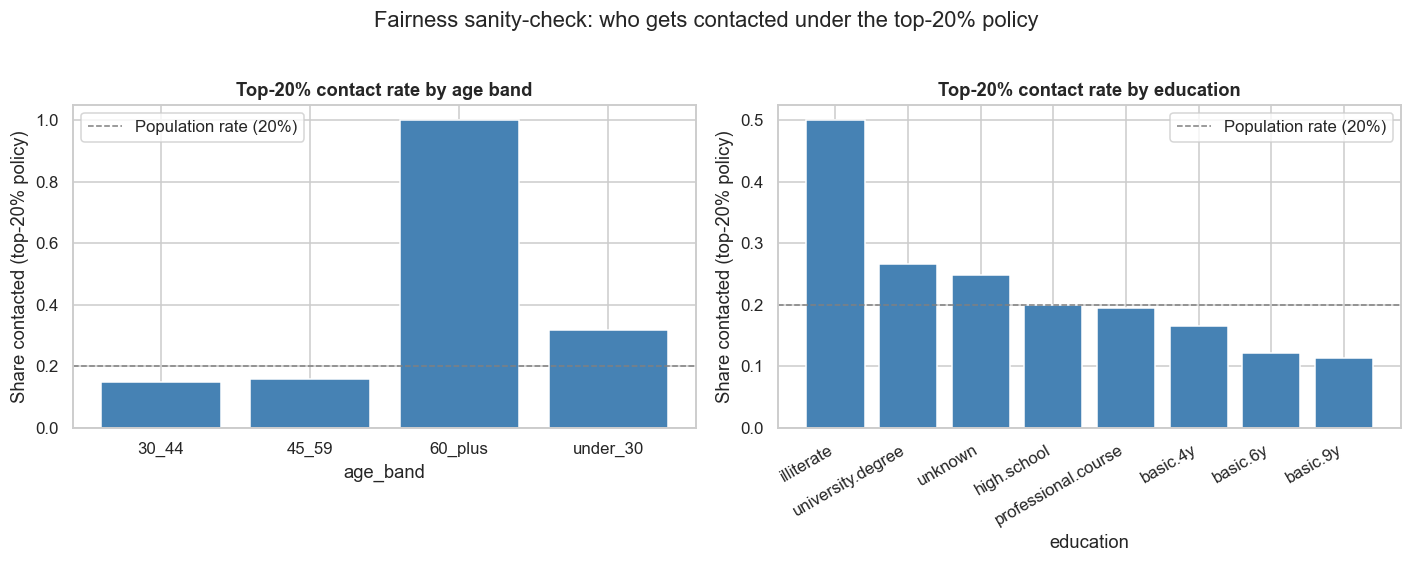

In [7]:
# --- 1×2 fairness figure: contact rate by age_band, then by education ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_plot = by_age.sort_values('age_band')
axes[0].bar(age_plot['age_band'], age_plot['top20pct_contact_rate'], color='steelblue')
axes[0].axhline(0.20, linestyle='--', color='grey', linewidth=1, label='Population rate (20%)')
axes[0].set_title('Top-20% contact rate by age band')
axes[0].set_xlabel('age_band')
axes[0].set_ylabel('Share contacted (top-20% policy)')
axes[0].legend(loc='upper left')

edu_plot = by_edu.sort_values('top20pct_contact_rate', ascending=False)
axes[1].bar(edu_plot['education'], edu_plot['top20pct_contact_rate'], color='steelblue')
axes[1].axhline(0.20, linestyle='--', color='grey', linewidth=1, label='Population rate (20%)')
axes[1].set_title('Top-20% contact rate by education')
axes[1].set_xlabel('education')
axes[1].set_ylabel('Share contacted (top-20% policy)')
axes[1].tick_params(axis='x', rotation=30)
for tick in axes[1].get_xticklabels():
    tick.set_horizontalalignment('right')
axes[1].legend(loc='upper right')

fig.suptitle('Fairness sanity-check: who gets contacted under the top-20% policy', y=1.02)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / '09_fairness.png', bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

## 9.6 — Concrete inputs for the compliance slide

Pull the three numbers the compliance officer will actually quote: top SHAP
features, the widest group disparity, and a pointer to the surrogate rules.


In [8]:
# --- Top 3 features by mean |SHAP| ---------------------------------------
top3 = top_features.head(3)

# --- Widest disparity in top-20% contact rate ----------------------------
def widest_gap(df: pd.DataFrame, group_col: str) -> tuple[str, str, float]:
    s = df.set_index(group_col)['top20pct_contact_rate']
    hi, lo = s.idxmax(), s.idxmin()
    return hi, lo, float(s.max() - s.min())

age_hi, age_lo, age_gap = widest_gap(by_age, 'age_band')
edu_hi, edu_lo, edu_gap = widest_gap(by_edu, 'education')

# Pair each disparity with its base-rate gap so we can tell whether the
# difference tracks real conversion behaviour or is being introduced by
# the model on top of it.
age_base_gap = float(
    by_age.set_index('age_band').loc[age_hi, 'base_rate']
    - by_age.set_index('age_band').loc[age_lo, 'base_rate']
)
edu_base_gap = float(
    by_edu.set_index('education').loc[edu_hi, 'base_rate']
    - by_edu.set_index('education').loc[edu_lo, 'base_rate']
)

print('=== Top 3 features by mean |SHAP| ===')
for feat, val in top3.items():
    print(f'  {feat:40s}  mean|SHAP| = {val:.4f}')

print('\n=== Widest contact-rate gaps (top-20% policy) ===')
print(f'  age_band:   {age_hi} vs {age_lo} — contact gap {age_gap:+.2%},  base-rate gap {age_base_gap:+.2%}')
print(f'  education:  {edu_hi} vs {edu_lo} — contact gap {edu_gap:+.2%},  base-rate gap {edu_base_gap:+.2%}')

print('\n=== Surrogate fallback ===')
print(f'  {n_leaves} decision regions, R² = {surrogate_r2:.3f} vs LightGBM scores')
print(f'  Saved to: {config.TABLES_DIR / "surrogate_rules.txt"}')

# Persist a plain-text compliance brief alongside the figures.
summary_lines = [
    '# Compliance brief — notebook 09',
    '',
    '## Top 3 features driving recommendations (mean |SHAP|)',
    *[f'- {feat}: {val:.4f}' for feat, val in top3.items()],
    '',
    '## Widest disparities under the top-20% contact policy',
    f'- age_band: {age_hi} contacted {age_gap:+.2%} more than {age_lo}; '
    f'underlying base-rate gap {age_base_gap:+.2%}.',
    f'- education: {edu_hi} contacted {edu_gap:+.2%} more than {edu_lo}; '
    f'underlying base-rate gap {edu_base_gap:+.2%}.',
    '',
    '## Fallback policy',
    f'- {n_leaves}-leaf depth-3 surrogate tree (R²={surrogate_r2:.3f}).',
    f'- Rules: outputs/tables/surrogate_rules.txt',
]
(config.TABLES_DIR / 'compliance_summary.txt').write_text('\n'.join(summary_lines))

=== Top 3 features by mean |SHAP| ===
  num__nr.employed                          mean|SHAP| = 0.3732
  num__euribor3m                            mean|SHAP| = 0.1923
  cat__contact_cellular                     mean|SHAP| = 0.1632

=== Widest contact-rate gaps (top-20% policy) ===
  age_band:   60_plus vs 30_44 — contact gap +85.08%,  base-rate gap +36.03%
  education:  illiterate vs basic.9y — contact gap +38.68%,  base-rate gap +41.47%

=== Surrogate fallback ===
  8 decision regions, R² = 0.877 vs LightGBM scores
  Saved to: C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\outputs\tables\surrogate_rules.txt


522

## 9.7 — Three-bullet compliance summary

- **What the model relies on.** Per `09_shap_bar.png`, the three highest mean-|SHAP| drivers on this run are `nr.employed` (0.37), `euribor3m` (0.19), and `contact_cellular` (0.16) — two macro-economic indicators plus the channel flag. None are protected attributes, and all are observable before a call is placed. The local waterfalls (`09_shap_local_recommend.png`, `09_shap_local_skip.png`) show the same small set of features explaining both the strongest contact recommendation and the strongest skip — the model isn't telling a different story at the two ends of the distribution.

- **Group disparities worth flagging.** Under the top-20% policy the `60_plus` age band is contacted at 100% vs ~15% for `30_44` (`09_fairness.png`, left panel). That +85 pp contact gap is largely **structural**: the underlying conversion rate for `60_plus` in the test set is ~46% vs ~10% for `30_44` (a +36 pp base-rate gap), so older customers genuinely convert more often — the disparity is justifiable but should be monitored. By education, the `illiterate` cell has only **n=2** and should be treated as noise; the real signal is that `university.degree` is contacted more than the `basic.*` levels, again tracking a real base-rate difference. Recommendation: on every retrain, recompute `fairness_by_age.csv` / `fairness_by_education.csv` and refuse to ship if the contact gap widens without a matching base-rate gap.

- **Fallback policy.** If the calibrated LightGBM service is offline, use the depth-3 surrogate tree in `outputs/tables/surrogate_rules.txt` as the documented backup. It reproduces the LightGBM scores with **R²≈0.88 across 8 decision regions** — enough fidelity for human-readable triage (e.g. "if `nr.employed` is low and the customer was previously contacted, expected probability ≈ 0.77"), but not a permanent replacement for the production model.
